# Aula 01 — Segmentação de Clientes por Regras

## Contexto
Você é analista de crédito num banco e recebeu uma base com **500 clientes** que pediram empréstimo pessoal.

O seu objetivo é **segmentar estes clientes em grupos de risco** usando apenas **regras que você mesmo vai definir** — sem nenhum algoritmo de Machine Learning.

No final, você vai descobrir se as suas regras funcionaram bem ou não, comparando com quem realmente ficou inadimplente.

---

## ⚠️ Antes de começar — faça o upload do ficheiro
1. Clique no ícone de pasta 📁 no painel esquerdo do Colab
2. Faça upload do ficheiro **`clientes_credito.csv`** (disponível no Discord)
3. Execute as células em ordem

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

print('Setup OK')

Setup OK


---
## Bloco 1 — Carregar a Base de Clientes

Cada linha é um cliente com:
- `idade`, `renda_mensal`, `score_credito` (300–900)
- `n_atrasos_12m` — quantas vezes atrasou pagamentos no último ano
- `valor_emprestimo` — quanto quer pedir
- `inadimplente` — **coluna secreta**: 1 se ficou inadimplente, 0 se não ficou

> ⚠️ Você **não pode usar** a coluna `inadimplente` para criar as suas regras. Ela só serve para avaliar no final!

In [6]:
# Carrega o ficheiro CSV que fizeste upload
df = pd.read_csv('clientes_credito.csv')

print(f'Base carregada: {df.shape[0]} clientes, {df.shape[1]} colunas')
df.head(8)

Base carregada: 500 clientes, 7 colunas


,id,idade,renda_mensal,score_credito,n_atrasos_12m,valor_emprestimo,inadimplente
0,1,56,2300.0,669,0,14500.0,0
1,2,69,3700.0,538,2,23100.0,0
2,3,46,3420.0,634,0,22600.0,0
3,4,32,3100.0,535,3,10100.0,1
4,5,60,11740.0,550,1,67800.0,1
5,6,25,5560.0,467,1,23900.0,0
6,7,38,2220.0,518,0,13800.0,1
7,8,56,7370.0,473,1,41600.0,0


---
## Bloco 2 — Conheça os Dados Antes de Criar Regras

Antes de segmentar, explore a base. Execute as células abaixo e **observe os padrões**.

In [7]:
# Estatísticas básicas (sem a coluna inadimplente)
df.drop(columns='inadimplente').describe().round(1)

,id,idade,renda_mensal,score_credito,n_atrasos_12m,valor_emprestimo
count,500.0,500.0,500.0,500.0,500.0,500.0
mean,250.5,44.7,5109.4,627.5,1.4,23010.4
std,144.5,15.2,3000.2,103.9,1.4,15693.3
min,1.0,18.0,1200.0,310.0,0.0,3300.0
25%,125.8,32.0,3027.5,555.8,0.0,12175.0
50%,250.5,45.0,4400.0,627.5,1.0,18950.0
75%,375.2,57.0,6305.0,691.5,2.0,29000.0
max,500.0,70.0,24180.0,891.0,4.0,100000.0


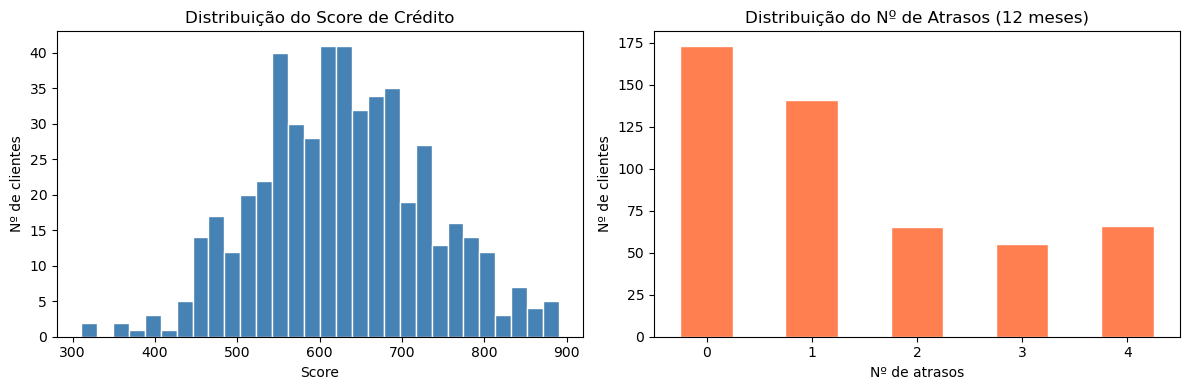

In [8]:
# Distribuição do score e dos atrasos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['score_credito'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Score de Crédito')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Nº de clientes')

df['n_atrasos_12m'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='coral', edgecolor='white')
axes[1].set_title('Distribuição do Nº de Atrasos (12 meses)')
axes[1].set_xlabel('Nº de atrasos')
axes[1].set_ylabel('Nº de clientes')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## Bloco 3 — Exemplo de Segmentação por UMA Regra

Veja como funciona uma segmentação simples, usando só o `score_credito`.

In [9]:
# EXEMPLO — segmentar por score
def segmento_exemplo(row):
    if row['score_credito'] >= 700:
        return 'Baixo Risco'
    elif row['score_credito'] >= 500:
        return 'Médio Risco'
    else:
        return 'Alto Risco'

df['segmento_exemplo'] = df.apply(segmento_exemplo, axis=1)

# Avaliação: taxa de inadimplência por segmento
resultado = df.groupby('segmento_exemplo')['inadimplente'].agg(
    qtd_clientes='count',
    n_inadimplentes='sum',
    taxa_inadimplencia='mean'
)
resultado['taxa_inadimplencia'] = (resultado['taxa_inadimplencia'] * 100).round(1)
resultado.columns = ['Qtd Clientes', 'Nº Inadimplentes', 'Taxa Inadimplência %']
print('=== Resultado da segmentação por score ===')
resultado

=== Resultado da segmentação por score ===


,Qtd Clientes,Nº Inadimplentes,Taxa Inadimplência %
segmento_exemplo,,,
Alto Risco,55,32,58.2
Baixo Risco,120,17,14.2
Médio Risco,325,78,24.0


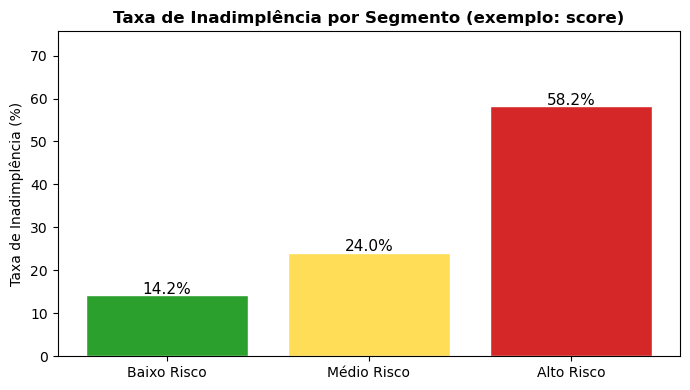

In [10]:
# Visualização do exemplo
ordem = ['Baixo Risco', 'Médio Risco', 'Alto Risco']
taxas = df.groupby('segmento_exemplo')['inadimplente'].mean() * 100
taxas = taxas.reindex(ordem)

plt.figure(figsize=(7, 4))
bars = plt.bar(taxas.index, taxas.values, color=['#2ca02c', '#ffdd57', '#d62728'], edgecolor='white')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.4, f'{h:.1f}%', ha='center', fontsize=11)
plt.title('Taxa de Inadimplência por Segmento (exemplo: score)', fontweight='bold')
plt.ylabel('Taxa de Inadimplência (%)')
plt.ylim(0, taxas.max() * 1.3)
plt.tight_layout()
plt.show()

---
## Exercício 1 — Segmentação por Atrasos

Agora é a sua vez. Crie uma segmentação usando **apenas** a coluna `n_atrasos_12m`.

**Pense:** quem tem mais atrasos tende a ser mais arriscado?

**Dica:** use `if/elif/else` igual ao exemplo acima. Escolha os limites que você achar que fazem sentido.

Depois compare a taxa de inadimplência por segmento — os grupos ficaram bem separados?

In [24]:
def segmento_atrasos(row):
    if row['n_atrasos_12m'] <= 0:
        return 'Baixo Risco'
    elif row['n_atrasos_12m'] <= 2:
        return 'Médio Risco'
    else:
        return 'Alto Risco'

df['seg_ex1'] = df.apply(segmento_atrasos, axis=1)

# Avalie o resultado:
df.groupby('seg_ex1')['inadimplente'].agg(
    qtd='count', n_inad='sum', taxa='mean'
).assign(taxa=lambda x: (x['taxa'] * 100).round(1))

,qtd,n_inad,taxa
seg_ex1,,,
Alto Risco,121,53,43.8
Baixo Risco,173,30,17.3
Médio Risco,206,44,21.4


---
## Exercício 2 — Segmentação com Duas Variáveis

Agora combine **score** e **atrasos** na mesma função para criar segmentos mais precisos.

**Sugestão de estrutura para pensar:**

| Score | Atrasos | Segmento sugerido |
|-------|---------|-------------------|
| Alto  | Poucos  | ? |
| Alto  | Muitos  | ? |
| Baixo | Poucos  | ? |
| Baixo | Muitos  | ? |

Você pode ter 2, 3 ou 4 segmentos — escolha o que fizer mais sentido para você.

In [32]:
def segmento_duas_variaveis(row):
 # 1. RISCO CRÍTICO: O pior dos dois mundos (Score muito baixo E muitos atrasos)
    if row['score_credito'] < 500 and row['n_atrasos_12m'] > 2:
        return 'Risco Crítico'
    
    # 2. ALTO RISCO: Score baixo OU muitos atrasos (mas não os dois juntos)
    elif row['score_credito'] < 500 or row['n_atrasos_12m'] > 2:
        return 'Alto Risco'
    
    # 3. BAIXO RISCO: Score excelente E nenhum atraso
    elif row['score_credito'] >= 700 and row['n_atrasos_12m'] <= 0:
        return 'Baixo Risco'
    
    # 4. MÉDIO RISCO: Situações intermediárias
    else:
        return 'Médio Risco'

df['segmento_duas_vars'] = df.apply(segmento_duas_variaveis, axis=1)

tabela_ex2 = df.groupby('segmento_duas_vars')['inadimplente'].agg(['count', 'mean']).reset_index()
tabela_ex2.columns = ['Segmento', 'Total', 'Taxa_Inadimplência']
tabela_ex2['Taxa_Inadimplência'] = tabela_ex2['Taxa_Inadimplência'].round(3)*100
print(tabela_ex2)
print(f"\nAmplitude: {tabela_ex2['Taxa_Inadimplência'].max() - tabela_ex2['Taxa_Inadimplência'].min():.3f}")

        Segmento  Total  Taxa_Inadimplência
0     Alto Risco    148                39.9
1    Baixo Risco     44                 6.8
2    Médio Risco    294                17.7
3  Risco Crítico     14                92.9

Amplitude: 86.100


---
## Exercício 3 — A Sua Melhor Segmentação

Este é o desafio principal: crie a segmentação que conseguir a **maior amplitude** entre os segmentos.

Você pode usar **qualquer variável** do dataset:
- `idade`
- `renda_mensal`
- `score_credito`
- `n_atrasos_12m`
- `valor_emprestimo`
- Ou combinações delas (ex: `valor_emprestimo / renda_mensal`)

**Meta:** superar a amplitude do exemplo dado na aula.  
**Dica:** pense em como as variáveis se combinam para indicar risco real.

In [50]:
def minha_melhor_segmentacao(row):
    # SEU CÓDIGO AQUI
    # Dica: pode criar variáveis auxiliares, ex: dti = row['valor_emprestimo'] / row['renda_mensal']
    dti = row['valor_emprestimo'] / row['renda_mensal']
    print(dti)


df['meu_segmento'] = df.apply(minha_melhor_segmentacao, axis=1)

tabela_ex3 = df.groupby('meu_segmento')['inadimplente'].agg(['count', 'mean']).reset_index()
tabela_ex3.columns = ['Segmento', 'Total', 'Taxa_Inadimplência']
tabela_ex3['Taxa_Inadimplência'] = tabela_ex3['Taxa_Inadimplência'].round(3)
print(tabela_ex3)
print(f"\nAmplitude: {tabela_ex3['Taxa_Inadimplência'].max() - tabela_ex3['Taxa_Inadimplência'].min():.3f}")

6.304347826086956
6.243243243243243
6.608187134502924
3.2580645161290325
5.7751277683134585
4.298561151079137
6.216216216216216
5.644504748982361
5.885234429671098
5.286624203821656
2.901554404145078
4.721407624633431
6.920492721164614
6.677740863787376
2.2183098591549295
2.8193832599118944
2.6591760299625467
5.627906976744186
6.083333333333333
3.08300395256917
4.521963824289406
6.205357142857143
5.664527956003666
4.729064039408867
4.957020057306591
4.539748953974895
3.4893184130213633
4.801980198019802
5.444839857651245
6.375838926174497
5.173745173745174
5.81151832460733
2.8024193548387095
4.3125
2.0562770562770565
3.2222222222222223
5.623678646934461
6.953125
2.5
4.0
5.998608211551844
3.026315789473684
4.767726161369193
5.658536585365853
5.086705202312139
2.9430379746835444
3.7783375314861463
5.929203539823009
4.782608695652174
2.028169014084507
5.804066543438077
2.1710526315789473
5.733882030178327
3.01707779886148
6.7913669064748206
3.8473767885532593
3.617021276595745
2.752293577

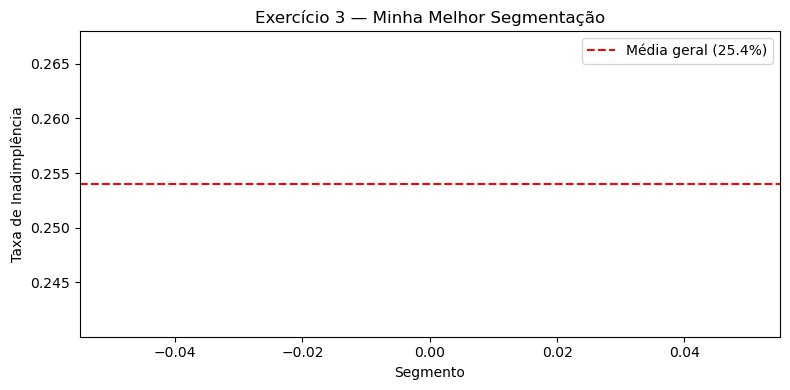

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tabela_ex3['Segmento'].astype(str), tabela_ex3['Taxa_Inadimplência'], color='steelblue', edgecolor='black')
ax.axhline(df['inadimplente'].mean(), color='red', linestyle='--', label=f'Média geral ({df["inadimplente"].mean():.1%})')
ax.set_xlabel('Segmento')
ax.set_ylabel('Taxa de Inadimplência')
ax.set_title('Exercício 3 — Minha Melhor Segmentação')
ax.legend()
plt.tight_layout()
plt.show()

---
## Bloco 4 — Comparação das Segmentações

Vamos comparar a amplitude de todas as segmentações criadas nesta aula.

> **Amplitude** = Taxa do segmento mais arriscado − Taxa do segmento menos arriscado  
> Quanto maior, mais útil é a segmentação para separar bons de maus pagadores.

In [15]:
def amplitude(df, coluna_segmento):
    taxas = df.groupby(coluna_segmento)['inadimplente'].mean()
    return taxas.max() - taxas.min()

resultados = {
    'Exemplo (score)':        amplitude(df, 'segmento_exemplo'),
    'Ex1 (atrasos)':          amplitude(df, 'segmento_atrasos'),
    'Ex2 (score + atrasos)':  amplitude(df, 'segmento_duas_vars'),
    'Ex3 (minha melhor)':     amplitude(df, 'meu_segmento'),
}

print("=" * 40)
print(f"{'Segmentação':<25} {'Amplitude':>10}")
print("=" * 40)
for nome, amp in resultados.items():
    print(f"{nome:<25} {amp:>10.3f}")
print("=" * 40)
print(f"\nMelhor amplitude: {max(resultados, key=resultados.get)} ({max(resultados.values()):.3f})")

KeyError: 'segmento_atrasos'

---
## Reflexão Final

Responda (mentalmente ou em comentário no código):

1. **Qual segmentação conseguiu a maior amplitude?** O que isso diz sobre as variáveis escolhidas?

2. **Quais foram as maiores dificuldades** ao definir as regras manualmente? O que você precisou testar?

3. **Imaginando que tivéssemos 50 variáveis** em vez de 6 — como seria possível encontrar as melhores combinações de regras sem testar manualmente?

---

> 💡 **Próximo passo:** Na próxima aula veremos como algoritmos de Machine Learning conseguem fazer exatamente isso de forma automática — encontrar os melhores critérios de separação nos dados, sem que o analista precise definir as regras uma a uma.